In [1]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import torch
torch.__version__

'2.10.0+cpu'

In [3]:
!pip install gpytorch
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 44.9 MB/s eta 0:00:00


In [4]:
import torch
import math
import gpytorch
import botorch
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib import cm
from gpytorch.kernels import MaternKernel, ScaleKernel, RBFKernel, LinearKernel, PeriodicKernel
from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, PosteriorMean
from botorch.acquisition.monte_carlo import SampleReducingMCAcquisitionFunction
from botorch.optim import optimize_acqf
from botorch.sampling import SobolQMCNormalSampler
from gpytorch.constraints.constraints import Interval
from gpytorch.likelihoods.gaussian_likelihood import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.utils.sampling import draw_sobol_samples
import botorch.sampling.get_sampler
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.objective import ConstrainedMCObjective
from gpytorch.priors import GammaPrior
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size':14})

# turn off warnings for clean output
import warnings
warnings.filterwarnings('ignore')

In [5]:
def save_plot(fig, plot_name, df, dpi=600):
    """
    Saves a Matplotlib figure as a PNG in the current working directory.
    The filename includes the plot name and the salt percentage (5 or 7.5).
    """
    salt = df["Salt_percentage"].iloc[0]
    salt_str = f"{salt}percent"

    filename = f"{plot_name}_{salt_str}.png"
    save_path = os.path.join(os.getcwd(), filename)

    fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0.15)
    print(f"Saved: {save_path}")

In [6]:
def get_highlight_points(df):
    """
    Returns:
        observed_color: str
        highlight_points: list of (df_high, color)
    """
    observed_color = "red"

    color_list = [
        "cyan", "magenta", "lime", "orange", "blue",
        "brown", "silver", "gold", "green", "chocolate", "orchid"
    ]

    highlight_points = []
    dataset_max = df["dataset"].max()

    if dataset_max == 1:
        idx = df["t_cross_days"].idxmax()
        df_high = df.loc[[idx]]
        highlight_points.append((df_high, "cyan"))
    else:
        for ds_id in range(1, dataset_max + 1):
            df_sub = df[df["dataset"] == ds_id]
            if len(df_sub) == 0:
                continue

            idx = df_sub["t_cross_days"].idxmax()
            df_high = df.loc[[idx]]
            color = color_list[(ds_id - 1) % len(color_list)]
            highlight_points.append((df_high, color))

    return observed_color, highlight_points

In [7]:
# Helper function that takes input data, kernel+likelihood specifications--> return trained model
def get_trained_GP(X, Y, kernel_type, noise_free=False,ls_floor = 0.20, ls_ceiling=3.0, noise_prior_mean=0.08):
    """
    This function is used to train a GP model based on the type of kernel that you select.
    This function will be used in modules 1,2,and 3. Save this function for later
    If you delete this cell accidentally, let us know!

    -----------
    Arg:
    X: Features/ Input vector -- torch tensor
    Y: Mapping/ Target variable vector -- torch tensor
    kernel_type: 'RBF'/'Linear'/'Periodic'/'Matern05'/'Matern15'/'Matern25' select one -- str
    noise_free: True or False (are observations noise free?)
    plot_1d: True or False (should we plot or not?)
    plot_bounds: Tuple of lower and upper bounds (xL, xU)

    ----------
    returns:

    model: a GP model object in train mode -- gpytorch
    """

    # make sure input data is shaped properly (ntrain by ninputs)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_train x n_inputs), got shape {X.shape}")

    if X.shape[-1]!=2:
        raise ValueError(f"Expected exactly 2 inputs (Polymer_thickness_mm, PCL_fraction), got {X.shape[-1]}")


    # make sure training data has the right dimension
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)
    elif Y.ndim!=2 or Y.shape[-1]!=1:
        raise ValueError(f"Y must be of shape (n,) or (n,1), got {Y.shape}")

    # --- model transforms (internal scaling) ---
    input_transform  = Normalize(d=2)
    outcome_transform = Standardize(m=1)

    # --- kernel with ARD + constraints ---
    ls_constraint = Interval(ls_floor, ls_ceiling)
    ls_prior      = GammaPrior(4.0, 6.0)        # mean ≈ 0.667 (soft prior, bound dominates)
    num_params = 2

    if kernel_type == "RBF":
        base_kernel = RBFKernel(ard_num_dims=num_params, lengthscale_prior=ls_prior, lengthscale_constraint=ls_constraint)
    elif kernel_type == "Matern25":
        base_kernel = MaternKernel(nu=2.5, ard_num_dims=num_params, lengthscale_prior=ls_prior, lengthscale_constraint=ls_constraint)

    covar_module = ScaleKernel(base_kernel)


    # --- likelihood (noise) ---
    # likelihood (GammaPrior(shape=2.0, rate=2/mean) → mean ≈ noise_prior_mean); GammaPrior(k/r); mean ~ = k/r
    rate = 2.0 / max(noise_prior_mean, 1e-6)

    if noise_free:
        likelihood = GaussianLikelihood(
            noise_prior=GammaPrior(2.0, 40.0),   # mean ~0.05
            noise_constraint=Interval(5e-4, 0.3),
        )
    else:
        likelihood = GaussianLikelihood(
            noise_prior=GammaPrior(2.0, rate),
            noise_constraint=Interval(1e-4, 0.5),
        )


    model = SingleTaskGP(
        train_X=X, # RAW physical units
        train_Y=Y,
        covar_module=covar_module,
        likelihood=likelihood,
        input_transform=input_transform,
        outcome_transform=outcome_transform
    )

    mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
    from botorch.fit import fit_gpytorch_mll
    with gpytorch.settings.cholesky_jitter(1e-3):
        fit_gpytorch_mll(mll)

    model.eval()


    # diagnostics
    hyp = model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
    print("ARD length-scales (normalized units):", hyp)
    print("Noise:", model.likelihood.noise.item())

    # return the trained model
    return model

In [8]:
def run_GP_and_Plot(df):
    # -----------------------------
    # 1. Fetching input and output
    # -----------------------------
    X_raw = torch.tensor(
        df[["Polymer_thickness_mm", "PCL_fraction"]].to_numpy(),
        dtype=torch.double,
    )
    Y_raw = torch.tensor(
        df["t_cross_days"].to_numpy(),
        dtype=torch.double,
    ).unsqueeze(-1)   # (n,1)


    salt = float(df["Salt_percentage"].iloc[0])
    if salt == 5.0:
        ls_floor = 0.24      # 0.24–0.25 for “camera‑ready”
        noise_mean = 0.08
    elif salt == 7.5:
        ls_floor = 0.24      # bump to 0.24 if slight ripple remains
        noise_mean = 0.10    # 0.10–0.12 only if ripple persists
    else:
        ls_floor = 0.20
        noise_mean = 0.08


    # -----------------------------
    # 2. RAW bounds (physical space) ---
    # -----------------------------
    thickness_min = 0.001
    thickness_max = 0.09
    fraction_min = 0.01
    fraction_max = 1.0
    x_min = torch.tensor([thickness_min, fraction_min], dtype=torch.double)
    x_max = torch.tensor([thickness_max, fraction_max], dtype=torch.double)
    bounds_phys = torch.stack([x_min, x_max])  # shape (2, 2)

    # -----------------------------
    # 3. Train GP on raw X, Y
    # -----------------------------
    model = get_trained_GP(
        X_raw,
        Y_raw,
        kernel_type="Matern25",
        noise_free=False,
        ls_floor=ls_floor,
        ls_ceiling=3.0,
        noise_prior_mean=noise_mean
    )

    # make sure model is double
    model = model.to(torch.double)

    # -----------------------------
    # 4) Constrained qEI in RAW space
    # -----------------------------

    # Build a sampler (handle older/newer BoTorch APIs)
    try:
        sampler = SobolQMCNormalSampler(sample_shape=torch.Size([1024]))
    except TypeError:
        sampler = SobolQMCNormalSampler(num_samples=1024)

    # Objective: maximize t_cross_days in RAW units
    def obj(samples, X=None):
        return samples.squeeze(-1)  # maximize t_cross_days

    # Constraint: feasible iff t_cross_days >= 0 (in original units)
    def constraint(samples, X=None):
        return (-samples).squeeze(-1)  # feasible if t_cross_days >= 0; need negative sign because this defaults to <0 for positive sign

    constrained_obj = ConstrainedMCObjective(
        objective=obj,
        constraints=[constraint],
        infeasible_cost=torch.tensor(-1e-3, dtype=torch.double),  # small negative to keep gradient signal
    )

    feas_mask = (Y_raw.squeeze(-1) >= 0)
    best_f = Y_raw[feas_mask].max().item() if feas_mask.any() else 0.0

    ei = qExpectedImprovement(
        model=model,
        best_f=best_f,
        sampler=sampler,
        objective=constrained_obj,
    )


    # -----------------------------
    # 5. Optimize EI in RAW to get next point
    # -----------------------------

    candidate, acq_value = optimize_acqf(
        acq_function=ei,
        bounds=bounds_phys,
        q=1, # number of next input values to determine
        num_restarts=20,
        raw_samples=512,
    )

    x_next = candidate[0]  # RAW

    Polymer_thickness_mm_next = float(x_next[0].item())
    PCL_fraction_next    = float(x_next[1].item())
    ei_next     = float(acq_value.item())

    print("Suggested next input (unscaled):")
    print(f"  Polymer_thickness_mm = {Polymer_thickness_mm_next:.6g}")
    print(f"  PCL_fraction    = {PCL_fraction_next:.6g}")
    print(f"EI at this point = {ei_next:.6g}")


    with torch.no_grad():
        post = model.posterior(x_next.unsqueeze(0))  # shape (1,3)
        pred_mean = post.mean.item()   # model predicts time in days to cross threshold
        std = post.variance.sqrt().item()

    print(f"\nGP-predicted time in days to cross the threshold at suggested point: {pred_mean:.6f}")
    print(f"GP uncertainty (std): {std:.6f}")

    bounds_dict = {
      "Polymer_thickness_mm": (thickness_min, thickness_max),
      "PCL_fraction": (fraction_min, fraction_max),
    }

    plot_gp_plus_ei_slice(
        "Polymer_thickness_mm",
        Polymer_thickness_mm_next, PCL_fraction_next,
        model, ei, bounds_dict, df
    )

    plot_gp_plus_ei_slice(
        "PCL_fraction",
        Polymer_thickness_mm_next, PCL_fraction_next,
        model, ei, bounds_dict, df
    )

    plot_gp_plus_ei_2d3d(model, ei, bounds_dict, df, n_grid=100)


In [9]:
def align_yzeros_pixel_exact(ax_left, ax_right, y_left=0.0, y_right=0.0,
                             ensure_zero_in_left=True, post_pad_right_max=None):
    """
    Align y=y_left on ax_left to y=y_right on ax_right at the exact same pixel height.
    Call this AFTER you finish plotting (including legends/tight_layout that may autoscale).

    Parameters
    ----------
    ax_left, ax_right : Matplotlib Axes
        ax_right should be created via ax_left.twinx().
    y_left, y_right : float
        Values to align (usually both 0.0).
    ensure_zero_in_left : bool
        Expand left y-limits a bit to include y_left if needed (recommended).
    post_pad_right_max : float or None
        If provided, ensures the right-axis top is >= this value to avoid clipping EI.
    """
    fig = ax_left.figure
    fig.canvas.draw()  # finalize transforms and autoscaled limits

    # Ensure y_left is inside left limits (alignment is ambiguous otherwise)
    y1_min, y1_max = ax_left.get_ylim()
    if ensure_zero_in_left and not (y1_min <= y_left <= y1_max):
        pad = 0.05 * (y1_max - y1_min + 1e-12)
        ax_left.set_ylim(min(y1_min, y_left) - pad, max(y1_max, y_left) + pad)
        fig.canvas.draw()
        y1_min, y1_max = ax_left.get_ylim()

    # Pixel row for y_left on the left axis
    ypix_target = ax_left.transData.transform((0.0, y_left))[1]

    # Left axis pixel span and fraction for y_left
    y1pix_min = ax_left.transData.transform((0.0, y1_min))[1]
    y1pix_max = ax_left.transData.transform((0.0, y1_max))[1]
    frac_left = (ypix_target - y1pix_min) / (y1pix_max - y1pix_min + 1e-12)

    # Keep the right data-span; shift its limits so y_right lands at the same fraction
    y2_min, y2_max = ax_right.get_ylim()
    span2 = (y2_max - y2_min) if (y2_max > y2_min) else 1.0
    new_y2_min = y_right - frac_left * span2
    new_y2_max = new_y2_min + span2
    ax_right.set_ylim(new_y2_min, new_y2_max)

    # Optional: ensure EI peak isn’t clipped
    if post_pad_right_max is not None:
        y2_min2, y2_max2 = ax_right.get_ylim()
        if y2_max2 < post_pad_right_max:
            ax_right.set_ylim(y2_min2, post_pad_right_max)

    fig.canvas.draw()

In [10]:
def plot_gp_plus_ei_slice(
    dim_name, Polymer_thickness_mm_val, PCL_fraction_val,
    model, ei_acq, bounds_dict, df
):
    """
    dim_name : "Polymer_thickness_mm", "PCL_fraction"
    Polymer_thickness_mm_val, PCL_fraction_val: slice location in *physical* space
    model : GP trained on *scaled* inputs and t_cross_days
    ei_acq : ExpectedImprovement object
    bounds_dict : {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_fraction_val":(...)} in physical space
    df : dataframe with columns ["Polymer_thickness_mm","PCL_fraction","t_cross_days"]
    """

    # -----------------------
    # 1) Build physical grid for the slice
    # -----------------------
    lower, upper = bounds_dict[dim_name]

    grid_phys = torch.linspace(lower, upper, 200, dtype=torch.double)

    if dim_name == "Polymer_thickness_mm":
        Polymer_thickness_mm_phys = grid_phys
        PCL_fraction_phys = torch.full_like(grid_phys, PCL_fraction_val, dtype=torch.double)
        x_label = "Polymer_thickness_mm"
        title_value = "PCL_fraction = {:.2f}".format(PCL_fraction_val)

    elif dim_name == "PCL_fraction":
        Polymer_thickness_mm_phys = torch.full_like(grid_phys, Polymer_thickness_mm_val, dtype=torch.double)
        PCL_fraction_phys = grid_phys
        x_label = "PCL_fraction"
        title_value = "Polymer_thickness_mm = {:.2f}".format(Polymer_thickness_mm_val)

    Xtest_phys = torch.stack([Polymer_thickness_mm_phys, PCL_fraction_phys], dim=1)   # RAW


    # -----------------------
    # 2) GP posterior (on t_cross_days)
    # -----------------------
    with torch.no_grad():
        post = model.posterior(Xtest_phys) # RAW → model normalizes internally
        mean = post.mean.squeeze(-1).cpu().numpy()
        std = post.variance.sqrt().squeeze(-1).cpu().numpy()
        print("STD range on this slice:", std.min(), std.max())

    # upper and lower confidence bounds
    lcb = mean - 2.0 * std
    lcb = np.maximum(lcb, 0)
    ucb = mean + 2.0 * std

    # -----------------------
    # 3) EI values on this slice
    # -----------------------
    with torch.no_grad():
        ei_vals = ei_acq(Xtest_phys.unsqueeze(1)).squeeze(-1).cpu().numpy()

    # -----------------------
    # 3) Observed points projected to this axis
    # -----------------------

    x_obs = df[{"Polymer_thickness_mm": "Polymer_thickness_mm", "PCL_fraction": "PCL_fraction"}[dim_name]].to_numpy()
    y_obs = df["t_cross_days"].to_numpy()
    x_grid_np = grid_phys.cpu().numpy()


    # -----------------------
    # 6) Plot
    # -----------------------

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # GP CI band
    ax1.fill_between(x_grid_np, lcb, ucb, color="lightblue", alpha=0.3, label="95% CI")

    # GP mean
    ax1.plot(x_grid_np, mean, color="blue", linewidth=2, label="GP mean")

    # Observed data
    observed_color, highlight_points = get_highlight_points(df)

    # ----------------------------------------------------
    # Build legend handles (same logic as main figure)
    # ----------------------------------------------------
    legend_handles = []

    # Observed points (LHS)
    h_obs = ax1.scatter([], [], c=observed_color, marker="x", s=40, label="LHS")
    legend_handles.append(h_obs)

    # Highlight points (LHS best, GP design1, GP design2, ...)
    dataset_max = df["dataset"].max()
    for i, (df_high, color) in enumerate(highlight_points):
        if dataset_max == 1:
            label = "LHS best"
        else:
            label = "LHS best" if i == 0 else f"GP design{i}"
        h = ax1.scatter([], [], c=color, marker="x", s=90, linewidths=2.5, label=label)
        legend_handles.append(h)

    # Observed points (mirrored color)
    ax1.scatter(
        x_obs,
        y_obs,
        c=observed_color,
        s=40,
        marker="x"
    )

    # Highlight points (mirrored colors)
    for df_high, color in highlight_points:
        ax1.scatter(
            df_high[dim_name],
            df_high["t_cross_days"],
            c=color,
            s=90,
            marker="x",
            linewidths=2.5
        )


    ax1.set_xlabel(x_label)
    ax1.set_ylabel("t_cross_days")
    ax1.grid(True)

    # EI on twin axis
    ax2 = ax1.twinx()
    ax2.plot(x_grid_np, ei_vals, color="orange", linestyle="--", linewidth=2, label="EI")
    ax2.set_ylabel("EI", color="orange")

    # ----------------------------------------------------
    # Shared bottom legend (2 rows, full width)
    # ----------------------------------------------------
    n_handles = len(legend_handles)
    ncol = int(np.ceil(n_handles / 3))   # split into 2 rows

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=ncol,
        frameon=True
    )

    plt.subplots_adjust(bottom=0.28)   # reserve space for 2-row legend

    plt.title(f"GP Posterior + EI Slice at {title_value}")
    fig.canvas.draw()
    plt.tight_layout()
    ax2.set_ylim(0, ei_vals.max()*1.05)
    # align zeroes between ax1 and ax2
    ei_cap = float(np.nanmax(ei_vals)) * 1.05 if np.isfinite(np.nanmax(ei_vals)) else None
    align_yzeros_pixel_exact(ax1, ax2, y_left=0.0, y_right=0.0,
                            ensure_zero_in_left=True,
                            post_pad_right_max=ei_cap)

    save_plot(fig, f"GP_EI_slice_{dim_name}", df)
    plt.show()


In [11]:
def plot_gp_plus_ei_2d3d(model, ei_acq, bounds_dict, df, n_grid=100):
    """
    model: GP trained on scaled inputs, predicting t_cross_days
    ei_acq: ExpectedImprovement object
    bounds_dict: {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_fraction": (Lmin,Lmax)}
    df: dataframe with columns ["Polymer_thickness_mm","PCL_fraction","t_cross_days"]
    x_min, x_max: tensors used for scaling
    """

    # -----------------------
    # 1) Build 2D physical grid
    # -----------------------
    th_min, th_max = bounds_dict["Polymer_thickness_mm"]
    pcl_min, pcl_max = bounds_dict["PCL_fraction"]

    th_grid = torch.linspace(th_min, th_max, n_grid, dtype=torch.double)
    pcl_grid = torch.linspace(pcl_min, pcl_max, n_grid, dtype=torch.double)

    TH, PCL = torch.meshgrid(th_grid, pcl_grid, indexing="ij")  # (n,n)

    X_phys = torch.stack([TH.reshape(-1), PCL.reshape(-1)], dim=1)  # RAW

    # -----------------------
    # 2) GP posterior & EI valuespl
    # -----------------------
    with torch.no_grad():
        post = model.posterior(X_phys)
        mean = post.mean.view(-1).cpu().numpy()
        std = post.variance.sqrt().view(-1).cpu().numpy()
        ei_vals = ei_acq(X_phys.unsqueeze(1)).view(-1).cpu().numpy()

    # -----------------------
    # 3) Reshape for plotting
    # -----------------------
    mean_2d = mean.reshape(n_grid, n_grid)
    std_2d = std.reshape(n_grid, n_grid)
    ei_2d = ei_vals.reshape(n_grid, n_grid)

    # -----------------------
    # 4) 2D mean and EI
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    # After computing mean_2d for each dataset, gather global limits:
    #vmin = min(mean_2d_5.min(),  mean_2d_7pt5.min())
    #vmax = max(mean_2d_5.max(),  mean_2d_7pt5.max())
    vmin = 0
    vmax = 225
    im0 = ax[0].imshow(
        mean_2d,
        origin="lower",
        extent=[pcl_min, pcl_max, th_min, th_max],
        aspect="auto",
        cmap="viridis",
        vmin = vmin, vmax=vmax,
    )
    ax[0].set_title("GP Posterior Mean (t_cross_days)")
    ax[0].set_xlabel("PCL_fraction")
    ax[0].set_ylabel("Polymer_thickness_mm")

    fig.colorbar(im0, ax=ax[0])

    # ----------------------------------------------------
    # Plot all observed points (red)
    # ----------------------------------------------------
    ax[0].scatter(
        df["PCL_fraction"],
        df["Polymer_thickness_mm"],
        c="red",
        s=40,
        marker="x",
        label="LHS"
    )

    cs = ax[0].contour(np.linspace(pcl_min,pcl_max,n_grid),
                   np.linspace(th_min,th_max,n_grid),
                   mean_2d, levels=10, colors="k",
                   linewidths=0.6, alpha=0.5)
    ax[0].clabel(cs, inline=True, fmt="%.0f", fontsize=9)

    # ----------------------------------------------------
    # NEW LOGIC: highlight based on t_cross_days
    # ----------------------------------------------------
    dataset_max = df["dataset"].max()

    # A palette with enough distinct colors
    color_list = ["cyan", "magenta", "lime", "orange","blue", "brown", "silver", "gold", "green", "chocolate", "orchid"]

    # We will collect legend handles manually
    legend_handles = []

    if dataset_max == 1:
        # Only one dataset → highlight the single highest t_cross_days
        idx = df["t_cross_days"].idxmax()
        df_high = df.loc[[idx]]

        h = ax[0].scatter(
            df_high["PCL_fraction"],
            df_high["Polymer_thickness_mm"],
            c="cyan",
            s=90,
            marker="x",
            linewidths=2.5,
            label="LHS best"
        )
        legend_handles.append(h)

    else:
        # Multiple datasets → highlight the max t_cross_days within each dataset
        for ds_id in range(1, dataset_max + 1):
            df_sub = df[df["dataset"] == ds_id]
            if len(df_sub) == 0:
                continue

            idx = df_sub["t_cross_days"].idxmax()
            df_high = df.loc[[idx]]

            color = color_list[(ds_id - 1) % len(color_list)]

            # Labeling rule:
            if ds_id == 1:
                label = "LHS best"
            else:
                label = f"GP design{ds_id - 1}"

            h = ax[0].scatter(
                df_high["PCL_fraction"],
                df_high["Polymer_thickness_mm"],
                c=color,
                s=90,
                marker="x",
                linewidths=2.5,
                label=label
            )
            legend_handles.append(h)


    # -----------------------
    # 7) Plot EI
    # -----------------------
    im1 = ax[1].imshow(ei_2d, origin="lower",
                       extent=[pcl_min, pcl_max, th_min, th_max],
                       aspect="auto", cmap="inferno")
    ax[1].set_title("Expected Improvement")
    ax[1].set_xlabel("PCL_fraction")
    ax[1].set_ylabel("Polymer_thickness_mm")
    fig.colorbar(im1, ax=ax[1])

    # Overlay observed points
    ax[1].scatter(df["PCL_fraction"], df["Polymer_thickness_mm"],
                  c="red", s=40, marker="x")

    # ----------------------------------------------------
    # Mirror highlight colors on EI panel
    # ----------------------------------------------------
    if dataset_max == 1:
        # Single dataset → highlight the single highest t_cross_days
        idx = df["t_cross_days"].idxmax()
        df_high = df.loc[[idx]]

        ax[1].scatter(
            df_high["PCL_fraction"],
            df_high["Polymer_thickness_mm"],
            c="cyan",          # same highlight color as left panel
            s=90,
            marker="x",
            linewidths=2.5
        )

    else:
        # Multiple datasets → highlight max t_cross_days within each dataset
        for ds_id in range(1, dataset_max + 1):
            df_sub = df[df["dataset"] == ds_id]
            if len(df_sub) == 0:
                continue

            idx = df_sub["t_cross_days"].idxmax()
            df_high = df.loc[[idx]]

            color = color_list[(ds_id - 1) % len(color_list)]

            ax[1].scatter(
                df_high["PCL_fraction"],
                df_high["Polymer_thickness_mm"],
                c=color,         # same per‑dataset color as left panel
                s=90,
                marker="x",
                linewidths=2.5
            )


    # ----------------------------------------------------
    # Shared legend for both subplots (bottom, 2 rows)
    # ----------------------------------------------------
    all_handles = [ax[0].collections[0]] + legend_handles
    n_handles = len(all_handles)
    ncol = int(np.ceil(n_handles / 2))   # split into 2 rows

    plt.tight_layout()

    fig.legend(
        handles=all_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.10),   # slightly lower to fit 2 rows
        ncol=ncol,
        frameon=True
    )

    plt.subplots_adjust(bottom=0.22)   # reserve more space for 2-row legend
    save_plot(fig, "GP_2D_mean_EI", df)

    """
    TH, PCL: meshgrid tensors (n,n)
    mean_2d, std_2d: numpy arrays (n,n)
    """

    # 95% confidence interval surfaces
    lcb_2d = mean_2d - 2 * std_2d
    lcb_2d = np.maximum(lcb_2d, 0)
    ucb_2d = mean_2d + 2 * std_2d



    # Convert to numpy for plotting
    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    #ax.set_proj_type('ortho')
    # explicit limits & aspect (prevents autoscale surprises)
    # After computing mean_2d for each dataset, gather global limits:
    #zmin = min(mean_2d_5.min(),  mean_2d_7pt5.min())
    #zmax = max(mean_2d_5.max(),  mean_2d_7pt5.max())
    zmin = 0
    zmax = 225
    ax.set_xlim(pcl_min, pcl_max)
    ax.set_ylim(th_min, th_max)
    ax.set_zlim(zmin, zmax)



    # Mean surface
    surf = ax.plot_surface(PCL_np, TH_np, mean_2d,
                    cmap="viridis", alpha=0.9, linewidth=0, antialiased=True)

    # Lower CI surface
    #ax.plot_surface(PCL_np, TH_np, lcb_2d,
    #                color="blue", alpha=0.25, linewidth=0)

    # Upper CI surface
    #ax.plot_surface(PCL_np, TH_np, ucb_2d,
    #                color="blue", alpha=0.25, linewidth=0)

    # Put colorbar in its own inset axes so it doesn't squeeze the 3D plot
    cax = fig.add_axes([0.825, 0.20, 0.02, 0.60])  # [left, bottom, width, height] in figure coords
    surf.set_clim(vmin=zmin, vmax=zmax)
    cb = fig.colorbar(surf, cax=cax)
    cb.ax.tick_params(labelsize=10)


    # Optionally set a nice view angle
    #ax.view_init(elev=25, azim=-60)


    ax.set_xlabel("PCL_fraction",labelpad=10, fontsize=12)
    ax.set_ylabel("Polymer_thickness_mm",labelpad=10, fontsize=12)
    ax.set_zlabel("t_cross_days", labelpad=10, fontsize=12)
    #ax.set_title("3D GP Posterior with 95% Confidence Surfaces")
    #ax.set_title("3D GP Posterior")



    plt.show()
    save_plot(fig, "GP_3D_posterior", df)



    """
    TH, PCL: meshgrid tensors (n,n)
    ei_2d: numpy array (n,n) of EI values
    """

    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    #ax.set_proj_type('ortho')

    ax.set_xlim(pcl_min, pcl_max)
    ax.set_ylim(th_min, th_max)

    ax.set_zlim(0, float(np.nanmax(ei_2d)) * 1.05)

    #ax.set_box_aspect((1,1,0.7))  # keep same 0.6 as above



    # EI surface
    surf = ax.plot_surface(PCL_np, TH_np, ei_2d,
                          cmap="inferno", linewidth=0,
                          antialiased=True, alpha=0.9)

    # Axis labels with padding and font size
    ax.set_xlabel("PCL_fraction", labelpad=10, fontsize=12)
    ax.set_ylabel("Polymer_thickness_mm", labelpad=10, fontsize=12)
    ax.set_zlabel("Expected Improvement", labelpad=10, fontsize=12)  # Increased labelpad

    # Title
    #ax.set_title("3D Expected Improvement Surface", pad=20)


    cax = fig.add_axes([0.825, 0.20, 0.02, 0.60])
    cb = fig.colorbar(surf, cax=cax)
    cb.ax.tick_params(labelsize=10)

    #ax.view_init(elev=25, azim=-60)


    plt.show()
    save_plot(fig, "GP_3D_EI_surface", df)


In [12]:
base_path = os.path.join(os.getcwd())# replace it with path relative your data location
df_all=pd.read_csv(os.path.join(base_path, "DataSheetForBO.csv"))
df_all.head()
df_5 = df_all.loc[df_all["Salt_percentage"] == 5.0]
print(df_5.head())
print(df_5.shape[0])


   Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_fraction  \
0              5.0     0.1665                0.0635        0.0500   
1              5.0     0.2114                0.0186        0.7064   
2              5.0     0.1594                0.0706        0.8557   
3              5.0     0.1975                0.0325        0.5760   
4              5.0     0.2150                0.0150        0.9500   

   Chi_fraction         a         b         c         d  t_cross_days  dataset  
0        0.9500  0.412983 -0.001172 -0.005274 -0.005258      0.000000        1  
1        0.2936  1.590128 -0.002963 -0.016275 -0.028405    192.038401        1  
2        0.1443  0.408224 -0.001218 -0.001515 -0.016210      0.000000        1  
3        0.4240  0.916568 -0.001859 -0.009994 -0.011066      4.137023        1  
4        0.0500  2.066897 -0.003750 -0.019521 -0.048441    221.699739        1  
20


ARD length-scales (normalized units): [0.24000002 1.37412839]
Noise: 0.002858425381830367
Suggested next input (unscaled):
  Polymer_thickness_mm = 0.0127727
  PCL_fraction    = 0.253254
EI at this point = 0.299291

GP-predicted time in days to cross the threshold at suggested point: 216.594523
GP uncertainty (std): 4.554177
STD range on this slice: 4.288619808762281 36.02256752226063
Saved: /content/GP_EI_slice_Polymer_thickness_mm_5.0percent.png


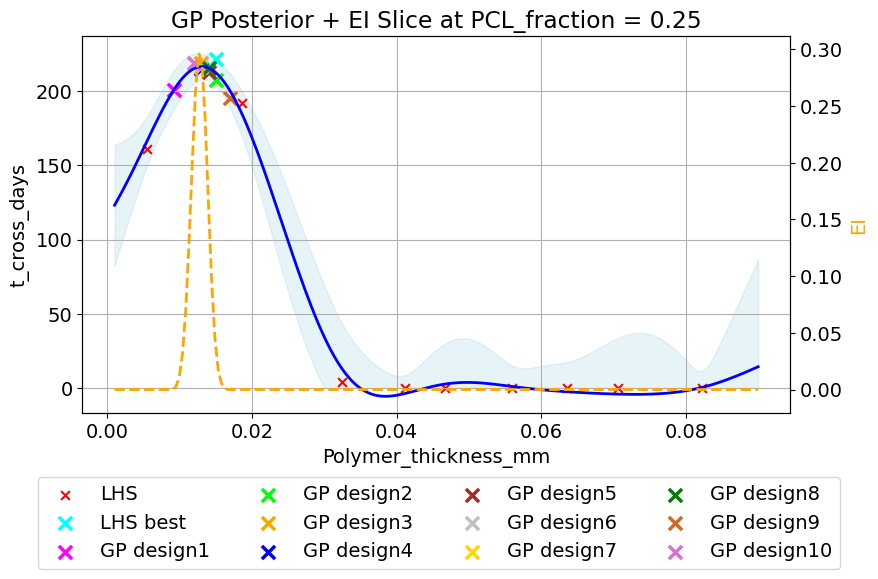

STD range on this slice: 2.5681410047034547 4.745450553697486
Saved: /content/GP_EI_slice_PCL_fraction_5.0percent.png


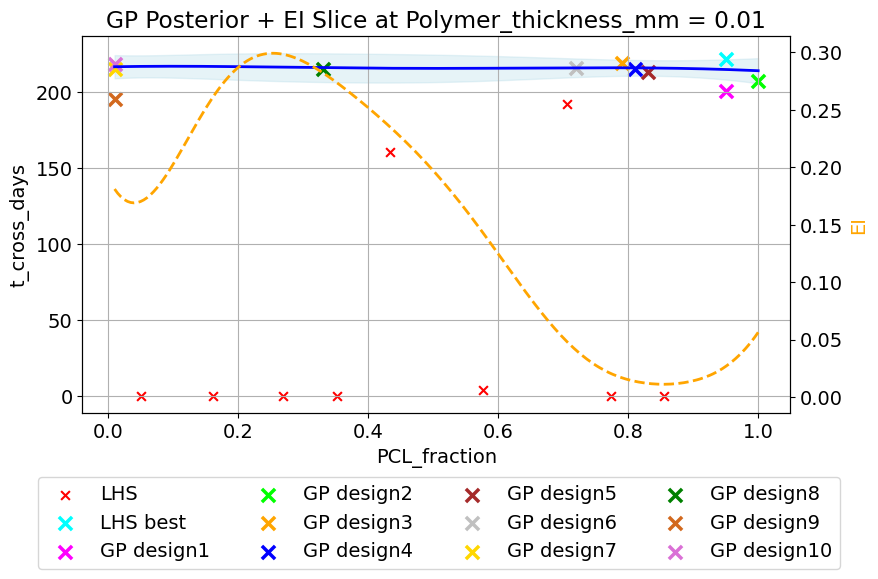

Saved: /content/GP_2D_mean_EI_5.0percent.png


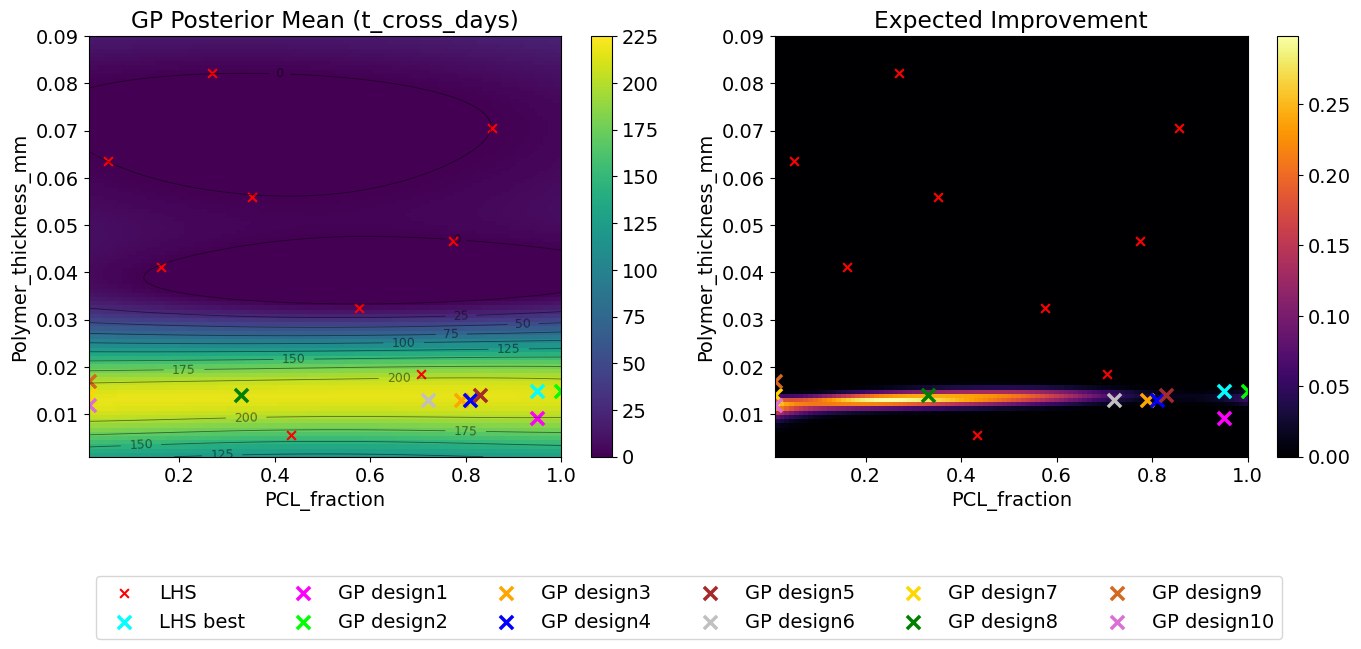

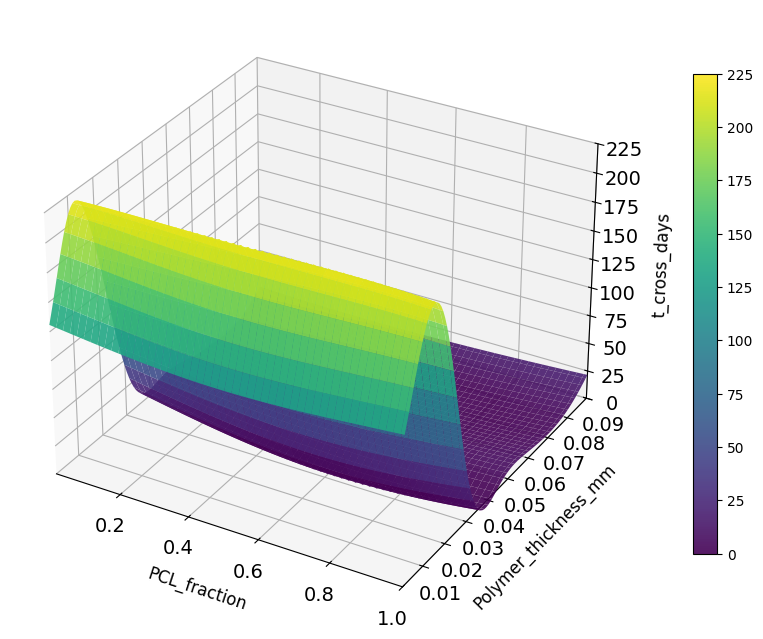

Saved: /content/GP_3D_posterior_5.0percent.png


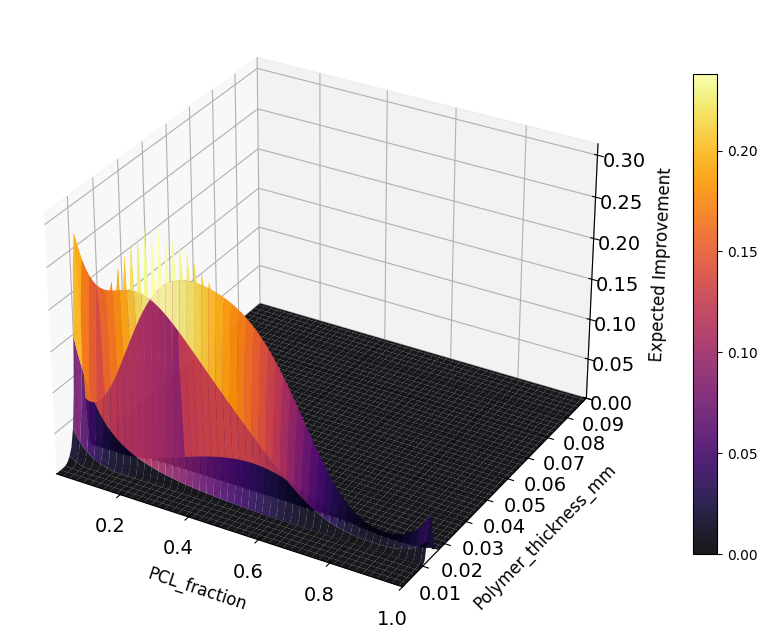

Saved: /content/GP_3D_EI_surface_5.0percent.png


In [13]:
df = df_5
run_GP_and_Plot(df)

In [14]:
df_7pt5 = df_all.loc[df_all["Salt_percentage"] == 7.5]
print(df_7pt5.head())
print(df_7pt5.shape[0])


    Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_fraction  \
10              7.5     0.1665                0.0635        0.0565   
11              7.5     0.2114                0.0186        0.7064   
12              7.5     0.1594                0.0706        0.8557   
13              7.5     0.1975                0.0325        0.5760   
14              7.5     0.2150                0.0150        0.9500   

    Chi_fraction         a         b         c         d  t_cross_days  \
10        0.9435  0.242147 -0.000779  0.000000 -0.000779      0.000000   
11        0.2936  1.566264 -0.003511 -0.027086 -0.023171    157.601684   
12        0.1443  0.558047 -0.001861 -0.004878 -0.015903      0.000000   
13        0.4240 -0.001413  0.005682  0.814502 -0.001710      0.000000   
14        0.0500  2.415579 -0.007702 -0.088515 -0.070965    128.190604   

    dataset  
10        1  
11        1  
12        1  
13        1  
14        1  
20


ARD length-scales (normalized units): [0.24000005 0.85697812]
Noise: 0.04749338187380319
Suggested next input (unscaled):
  Polymer_thickness_mm = 0.0115897
  PCL_fraction    = 0.449427
EI at this point = 0.465586

GP-predicted time in days to cross the threshold at suggested point: 171.820317
GP uncertainty (std): 7.329910
STD range on this slice: 7.3213118900995395 34.84053990741174
Saved: /content/GP_EI_slice_Polymer_thickness_mm_7.5percent.png


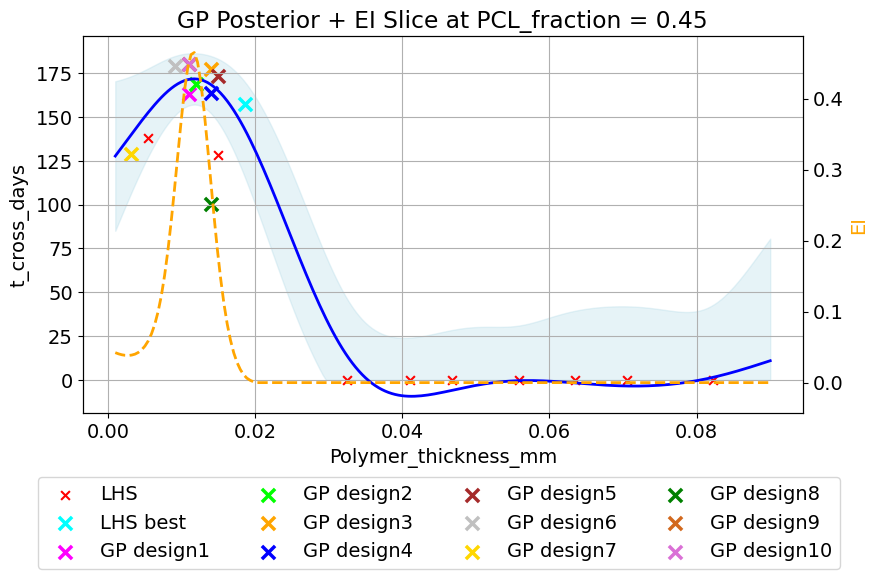

STD range on this slice: 6.771752857792563 19.00370683722539
Saved: /content/GP_EI_slice_PCL_fraction_7.5percent.png


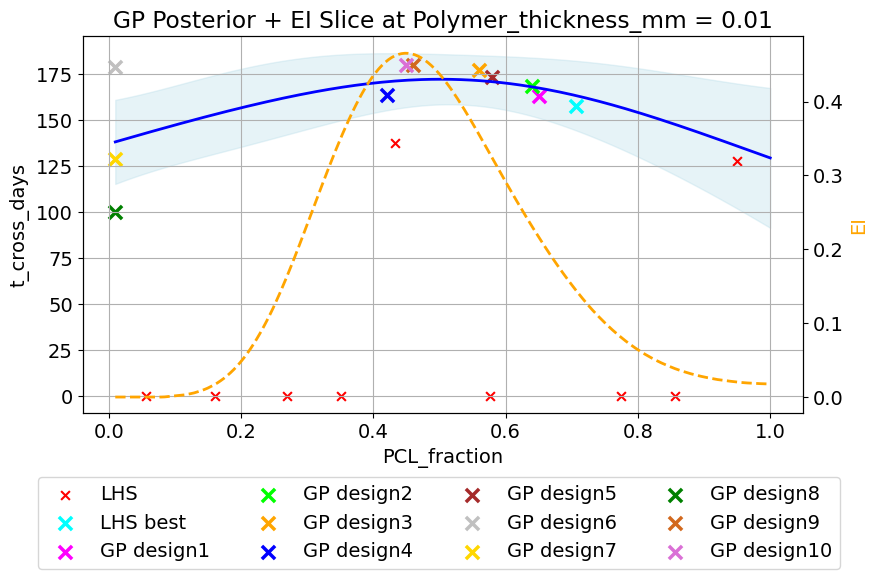

Saved: /content/GP_2D_mean_EI_7.5percent.png


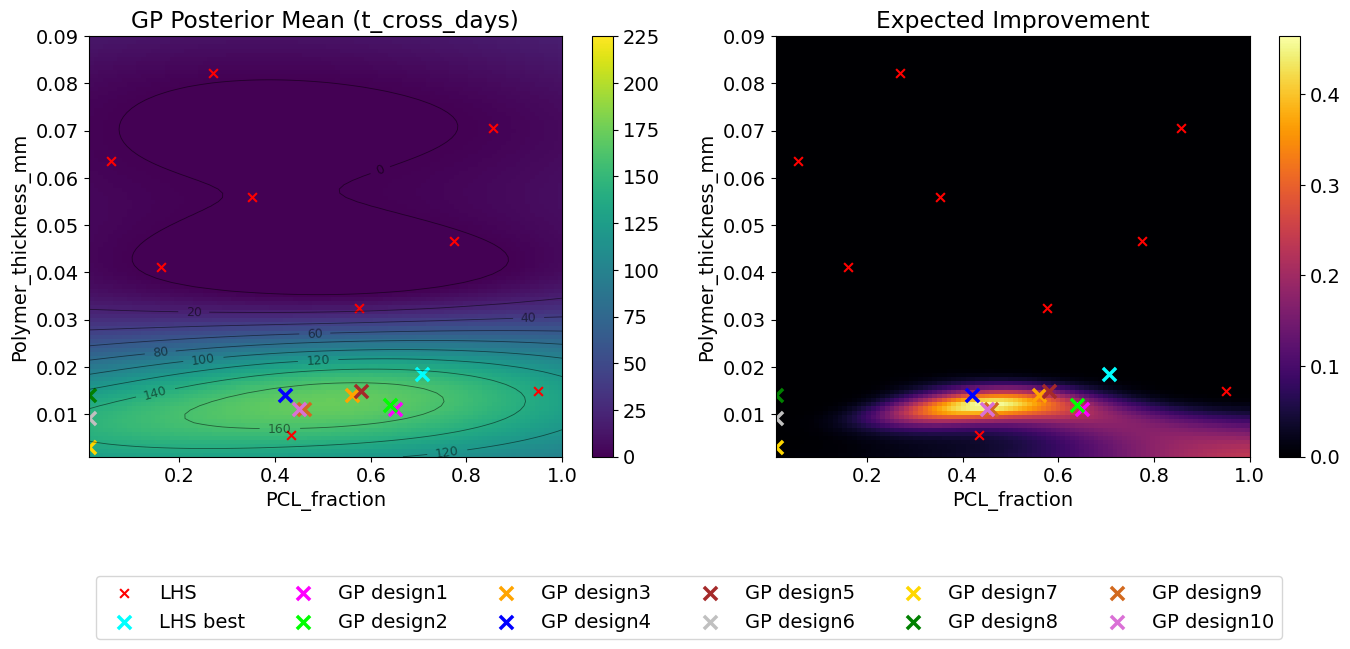

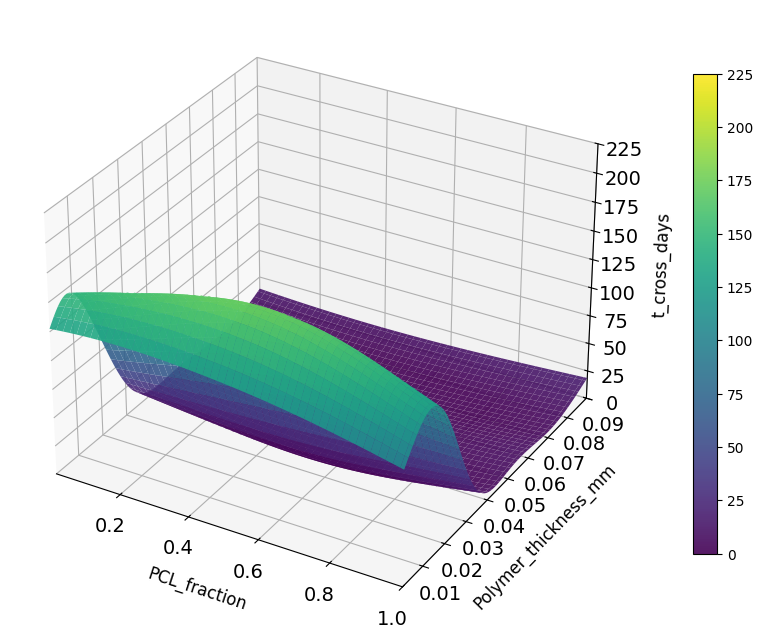

Saved: /content/GP_3D_posterior_7.5percent.png


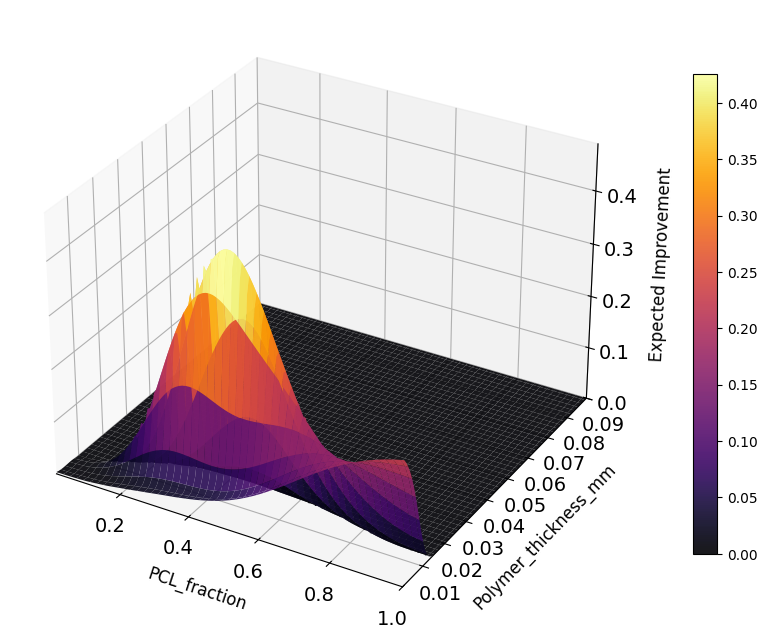

Saved: /content/GP_3D_EI_surface_7.5percent.png


In [15]:
df = df_7pt5
run_GP_and_Plot(df)